In [29]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.nuts import nuts


In [30]:
beta_true = jnp.log(0.3)
gamma_true = jnp.log(0.1)

t_vec = jnp.linspace(0,100,100)

def rhs(t,state,args):
    S,I,R = state
    N = S + I + R

    beta,gamma = args

    beta = jnp.exp(beta)
    gamma = jnp.exp(gamma)

    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

In [31]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Euler(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [32]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
full_state = jnp.maximum(model(t_vec,jnp.array([100.,1.0,0.0]),(beta_true,gamma_true)),1e-6)

observations = jax.random.poisson(noise_key,full_state[:,1])


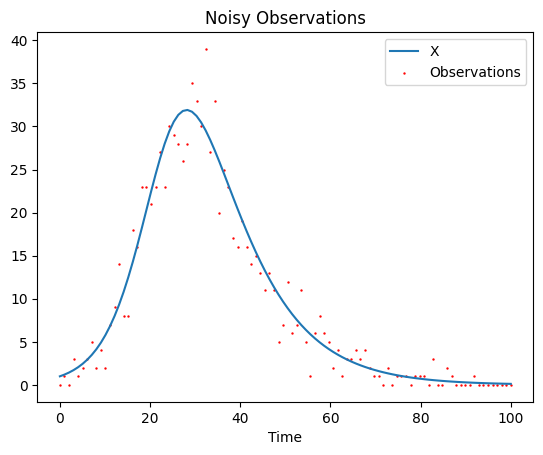

In [33]:
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,1],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [34]:

def log_likelihood(par):
    beta, gamma = par
    model_output = jnp.maximum(model(t_vec, jnp.array([100.0, 1.0,0.0]), (beta,gamma)),1e-6)
    return jnp.sum(
        jax.scipy.stats.poisson.logpmf(
            observations, model_output[:, 1], 
        )
    )

def prior(par):
    beta,gamma = par
    return jax.scipy.stats.norm.logpdf(beta,0.0,1.0) + jax.scipy.stats.norm.logpdf(gamma,0.0,1.0)

def joint(par): 
    return log_likelihood(par) + prior(par)

In [35]:
func = jax.jit(jax.value_and_grad(joint))

D = 2
M = 1000
Madapt = 100
key = jax.random.key(0)
init_key,key = jax.random.split(key)

theta0 = jnp.array([jnp.log(0.1),jnp.log(0.1)])

nuts_key,key = jax.random.split(key)
t0 = perf_counter()
samples, lnprob = nuts(func, M, Madapt, theta0,key = nuts_key,epsilon = 0.005)
t1 = perf_counter()
print(f'Done. runtime {t1 - t0} seconds')


Done. runtime 397.830817812006 seconds


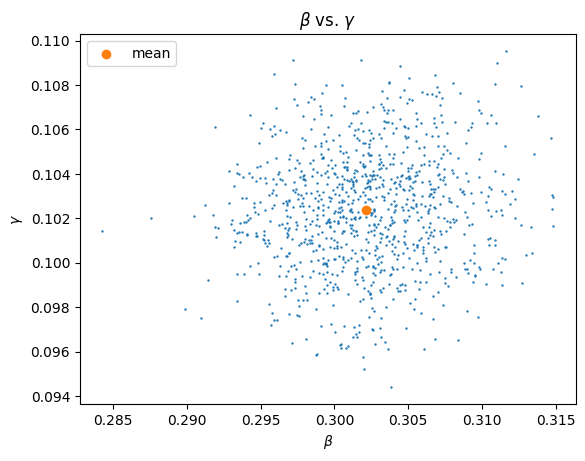

In [36]:
plt.title('$\\beta$ vs. $\\gamma$')
plt.xlabel('$\\beta$')
plt.ylabel("$\\gamma$")

plt.scatter(jnp.exp(samples[0,:,0]),jnp.exp(samples[0,:,1]),s = 0.5)

mean = jnp.mean(jnp.exp(samples[0,:]),axis = 0)
plt.scatter(mean[0],mean[1],label = 'mean')
plt.legend()